In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import scipy as sp

In [2]:
Data_PSH = pd.read_csv("./PS-H_Standard.csv")
Data_PSL = pd.read_csv("./PS-L_Standard.csv")

# Fitting the Standards

In [3]:
def ConvertPSH_mp_rv(MpValues):
    x = np.array(Data_PSH.rv)
    y = np.log(np.array(Data_PSH.Mp))
    coefficients = np.polyfit(y,x,3)
    p = np.poly1d(coefficients)
    LoggedRvValues = p(np.log(MpValues))
    RvValues = LoggedRvValues
    return RvValues

(4.0, 28.0)

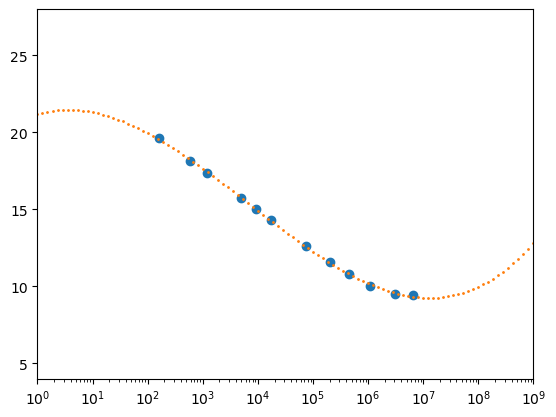

In [4]:
PSHSomeMpValues = np.logspace(0,9,100)
PSHSomeRvValues = ConvertPSH_mp_rv(PSHSomeMpValues)

plt.scatter(Data_PSH.Mp,Data_PSH.rv)
plt.scatter(PSHSomeMpValues,PSHSomeRvValues,s=1)
plt.xlim(1,1000000000)
plt.xscale('log')
plt.ylim(4,28)

(4.0, 28.0)

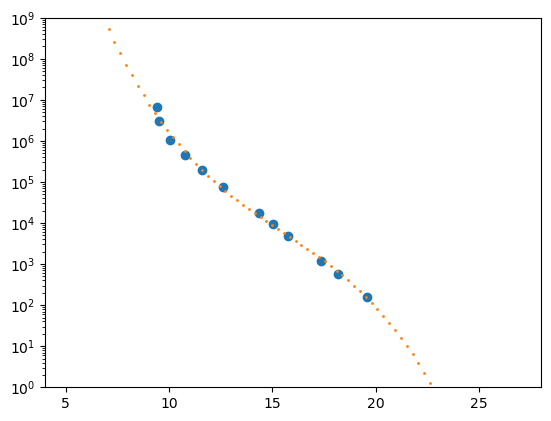

In [5]:
def ConvertPSH_rv_mp(RvValues):
    x = np.array(Data_PSH.rv)
    y = np.log(np.array(Data_PSH.Mp))
    # plt.scatter(x,y)

    coefficients = np.polyfit(x,y,3)
    p = np.poly1d(coefficients)
    xp = np.linspace(np.min(Data_PSH.rv),np.max(Data_PSH.rv),100)
    # plt.scatter(xp,p(xp))
    
    LoggedMpValues = p(RvValues)
    MpValues = np.exp(LoggedMpValues)
    return MpValues

PSHSomeRvValues = np.linspace(0,28,100)
PSHSomeMpValues = ConvertPSH_rv_mp(PSHSomeRvValues)

plt.scatter(Data_PSH.rv,Data_PSH.Mp)
plt.scatter(PSHSomeRvValues,PSHSomeMpValues,s=1)
plt.ylim(1,1000000000)
plt.yscale('log')
plt.xlim(4,28)

(4.0, 28.0)

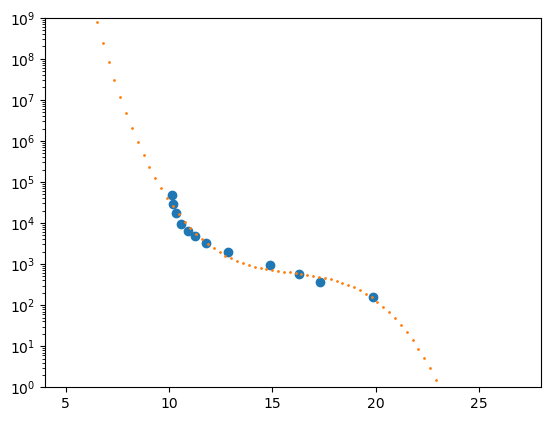

In [6]:
def ConvertPSL_rv_mp(RvValues):
    x = np.array(Data_PSL.rv)
    y = np.log(np.array(Data_PSL.Mp))
    coefficients = np.polyfit(x,y,3)
    p = np.poly1d(coefficients)
    xp = np.linspace(np.min(Data_PSL.rv),np.max(Data_PSL.rv),100)
    LoggedMpValues = p(RvValues)
    MpValues = np.exp(LoggedMpValues)
    return MpValues

PSLSomeRvValues = np.linspace(0,28,100)
PSLSomeMpValues = ConvertPSL_rv_mp(PSLSomeRvValues)

plt.scatter(Data_PSL.rv,Data_PSL.Mp)
plt.scatter(PSLSomeRvValues,PSLSomeMpValues,s=1)
plt.ylim(1,1000000000)
plt.yscale('log')
plt.xlim(4,28)

# Plotting Standard Overlays

In [7]:
Data_HMWR_PPI = pd.read_csv("./HMWR_PPI.csv")
Data_HMWR_PPSI = pd.read_csv("./HMWR_PPSI.csv")
Data_LMWR_PPI = pd.read_csv("./LMWR_PPI.csv")
Data_LMWR_PPSI = pd.read_csv("./LMWR_PPSI.csv")

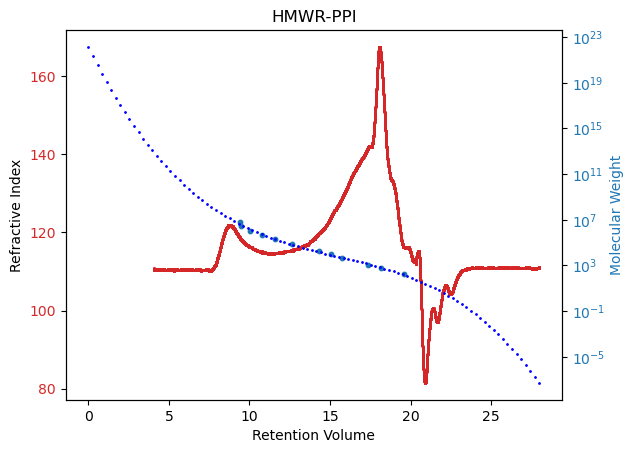

In [8]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPI")
color = 'tab:red'
ax1.set_ylabel("Refractive Index")
ax1.set_xlabel("Retention Volume")
ax1.scatter(Data_HMWR_PPI.rv,Data_HMWR_PPI.ri,color=color,s=1)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Molecular Weight',color=color)
ax2.scatter(Data_PSH.rv,Data_PSH.Mp,color=color,s=10)
ax2.scatter(PSHSomeRvValues,PSHSomeMpValues,color='blue',s=1)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

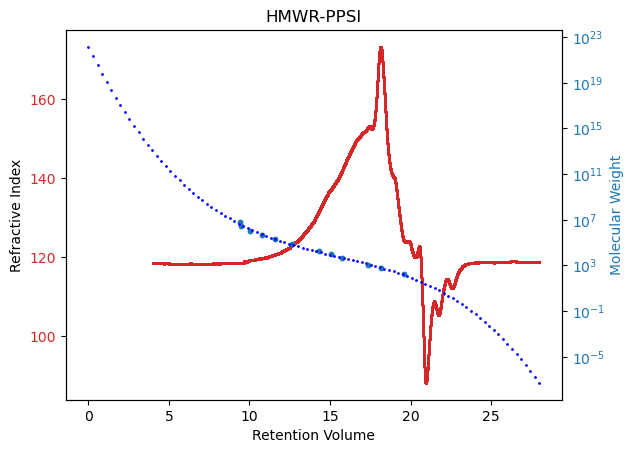

In [9]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPSI")
color = 'tab:red'
ax1.set_ylabel("Refractive Index")
ax1.set_xlabel("Retention Volume")
ax1.scatter(Data_HMWR_PPSI.rv,Data_HMWR_PPSI.ri,color=color,s=1)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Molecular Weight',color=color)
ax2.scatter(Data_PSH.rv,Data_PSH.Mp,color=color,s=10)
ax2.scatter(PSHSomeRvValues,PSHSomeMpValues,color='blue',s=1)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

In [10]:
def AnXAxisCutter(LowerLimit,UpperLimit,Dataframe):
    StartIdx = 0
    EndIdx = len(Dataframe)-1
    LowerLimitIdx = 0
    UpperLimitIdx = 0
    for count,i in enumerate(Dataframe.rv):
        if i > LowerLimit:
            LowerLimitIdx = count
            break
    for count,i in enumerate(Dataframe.rv):
        if i > UpperLimit:
            UpperLimitIdx = count
            break
    FirstDropRange = np.linspace(StartIdx,LowerLimitIdx,(LowerLimitIdx-StartIdx)+1).astype(int).tolist()
    SecondDropRange = np.linspace(UpperLimitIdx,EndIdx,(EndIdx-UpperLimitIdx)+1).astype(int).tolist()
    NewDataframe = Dataframe.drop(FirstDropRange)
    NewestDataframe = NewDataframe.drop(SecondDropRange)
    return NewestDataframe

In [11]:
Data_HMWR_PPI_CutOff = AnXAxisCutter(7.6,20.2,Data_HMWR_PPI)
Data_HMWR_PPI_ALT_CutOff = AnXAxisCutter(9.5,20.2,Data_HMWR_PPI)
Data_HMWR_PPSI_CutOff = AnXAxisCutter(9.4,20.4,Data_HMWR_PPSI)

# Conversion of X Axes

In [12]:
Data_HMWR_PPI_rv = np.array(Data_HMWR_PPI_CutOff.rv).tolist()
Data_HMWR_PPI_ALT_rv = np.array(Data_HMWR_PPI_ALT_CutOff.rv).tolist()
Data_HMWR_PPSI_rv = np.array(Data_HMWR_PPSI_CutOff.rv).tolist()

Data_HMWR_PPI_mp = list(reversed(ConvertPSH_rv_mp(Data_HMWR_PPI_CutOff.rv)))
Data_HMWR_PPI_ALT_mp = list(reversed(ConvertPSH_rv_mp(Data_HMWR_PPI_ALT_CutOff.rv)))
Data_HMWR_PPSI_mp = list(reversed(ConvertPSH_rv_mp(Data_HMWR_PPSI_CutOff.rv)))

Data_HMWR_PPI_ri_init = list(reversed(np.array(Data_HMWR_PPI_CutOff.ri).tolist()))
Data_HMWR_PPI_ALT_ri_init = list(reversed(np.array(Data_HMWR_PPI_ALT_CutOff.ri).tolist()))
Data_HMWR_PPSI_ri_init = list(reversed(np.array(Data_HMWR_PPSI_CutOff.ri).tolist()))

# The tail section of the PPSI plot
TailCut = 6750
Tail_Data_HMWR_PPSI_rv = Data_HMWR_PPSI_rv[TailCut::]
Tail_Data_HMWR_PPSI_mp = Data_HMWR_PPSI_mp[TailCut::]
Tail_Data_HMWR_PPSI_ri_init = Data_HMWR_PPSI_ri_init[TailCut::]

# Refractive Index Adjusted Tail Sections
TailAdjustment = -10
AdjustedTail_Data_HMWR_PPSI_rv = np.array(Tail_Data_HMWR_PPSI_rv)+TailAdjustment
AdjustedTail_Data_HMWR_PPSI_mp = np.array(Tail_Data_HMWR_PPSI_mp)+TailAdjustment
AdjustedTail_Data_HMWR_PPSI_ri_init = np.array(Tail_Data_HMWR_PPSI_ri_init)+TailAdjustment

# Narrowed Tail Section
NarrowingFactors = np.linspace(0,2,len(Tail_Data_HMWR_PPSI_ri_init))
NarrowedTail_Data_HMWR_PPSI_rv = AdjustedTail_Data_HMWR_PPSI_rv
NarrowedTail_Data_HMWR_PPSI_mp = AdjustedTail_Data_HMWR_PPSI_mp
NarrowedTail_Data_HMWR_PPSI_ri_init = AdjustedTail_Data_HMWR_PPSI_ri_init+NarrowingFactors

# The To-Be-Modified Datasets
ToBeModCut = TailCut-290
ToBeMod_HMWR_PPI_rv = np.array(Data_HMWR_PPI_rv)[:ToBeModCut]
ToBeMod_HMWR_PPI_mp = np.array(Data_HMWR_PPI_mp)[:ToBeModCut]
ToBeMod_HMWR_PPI_ri_init = np.array(Data_HMWR_PPI_ri_init)[:ToBeModCut]

# Modified Datasets
Data_HMWR_PPI_MOD_rv = np.append(ToBeMod_HMWR_PPI_rv,NarrowedTail_Data_HMWR_PPSI_rv)
Data_HMWR_PPI_MOD_mp = np.append(ToBeMod_HMWR_PPI_mp,NarrowedTail_Data_HMWR_PPSI_mp)
Data_HMWR_PPI_MOD_ri_init = np.append(ToBeMod_HMWR_PPI_ri_init,NarrowedTail_Data_HMWR_PPSI_ri_init)

# A separate set of datasets for just the tail
Data_HMWR_PPI_NT_rv = NarrowedTail_Data_HMWR_PPSI_rv
Data_HMWR_PPI_NT_mp = NarrowedTail_Data_HMWR_PPSI_mp
Data_HMWR_PPI_NT_ri_init = NarrowedTail_Data_HMWR_PPSI_ri_init

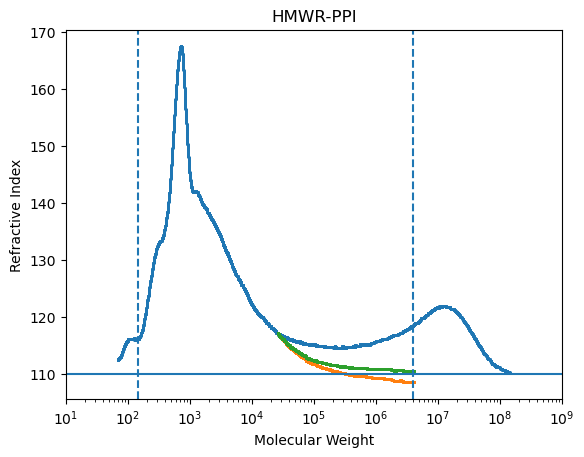

In [13]:
plt.title("HMWR-PPI")
plt.scatter(Data_HMWR_PPI_mp,Data_HMWR_PPI_ri_init,s=1)
plt.scatter(AdjustedTail_Data_HMWR_PPSI_mp,AdjustedTail_Data_HMWR_PPSI_ri_init,s=1)
plt.scatter(NarrowedTail_Data_HMWR_PPSI_mp,NarrowedTail_Data_HMWR_PPSI_ri_init,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.hlines(xmin=10,xmax=1000000000,y=110)
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

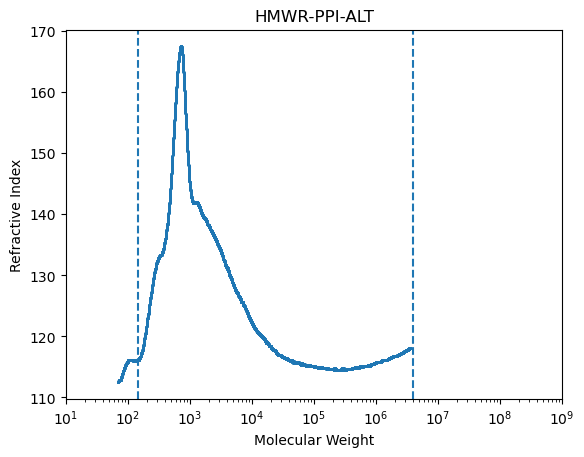

In [14]:
plt.title("HMWR-PPI-ALT")
plt.scatter(Data_HMWR_PPI_ALT_mp,Data_HMWR_PPI_ALT_ri_init,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

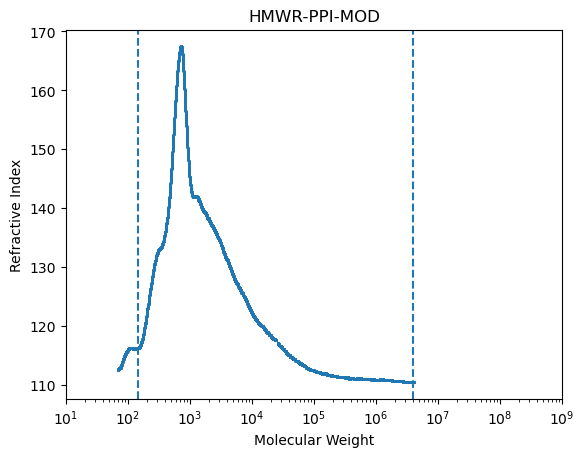

In [15]:
plt.title("HMWR-PPI-MOD")
plt.scatter(Data_HMWR_PPI_MOD_mp,Data_HMWR_PPI_MOD_ri_init,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

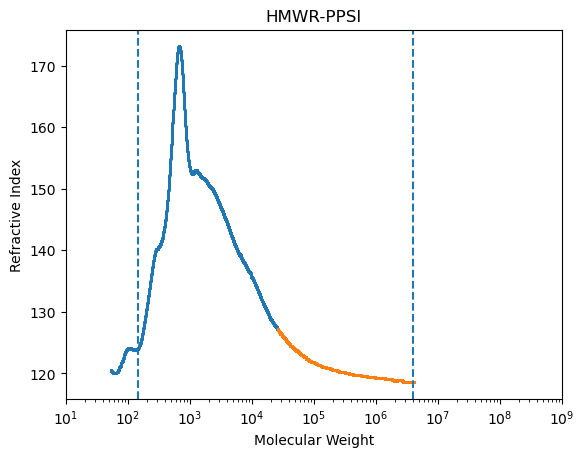

In [16]:
plt.title("HMWR-PPSI")
plt.scatter(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri_init,s=1)
plt.scatter(Tail_Data_HMWR_PPSI_mp,Tail_Data_HMWR_PPSI_ri_init,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

# Baseline Corrected Y Axes

In [17]:
Baseline_HMWR_PPI = np.array(Data_HMWR_PPI_ri_init)[-1]
Baseline_HMWR_PPI_ALT = np.array(Data_HMWR_PPI_ri_init)[-1]
Baseline_HMWR_PPI_MOD = np.array(Data_HMWR_PPI_ri_init)[-1]
Baseline_HMWR_PPI_NT = np.array(Data_HMWR_PPI_ri_init)[-1]
Baseline_HMWR_PPSI = np.array(Data_HMWR_PPSI_ri_init)[-1]

In [18]:
Baseline_HMWR_PPI

110.19293895408455

In [19]:
Baseline_HMWR_PPSI

118.52113622417866

In [20]:
def RemoveBaseline(Baseline,RawData):
    ProcessedData = []
    for i in RawData:
        j = i-Baseline
        if j < 0:
            ProcessedDatum = 0
            ProcessedData.append(ProcessedDatum)
        else:
            ProcessedDatum = j
            ProcessedData.append(ProcessedDatum)
    return ProcessedData

In [21]:
Data_HMWR_PPI_ri = RemoveBaseline(Baseline_HMWR_PPI,Data_HMWR_PPI_ri_init)
Data_HMWR_PPI_ALT_ri = RemoveBaseline(Baseline_HMWR_PPI_ALT,Data_HMWR_PPI_ALT_ri_init)
Data_HMWR_PPI_MOD_ri = RemoveBaseline(Baseline_HMWR_PPI_MOD,Data_HMWR_PPI_MOD_ri_init)
Data_HMWR_PPI_NT_ri = RemoveBaseline(Baseline_HMWR_PPI_NT,Data_HMWR_PPI_NT_ri_init)
Data_HMWR_PPSI_ri = RemoveBaseline(Baseline_HMWR_PPSI,Data_HMWR_PPSI_ri_init)

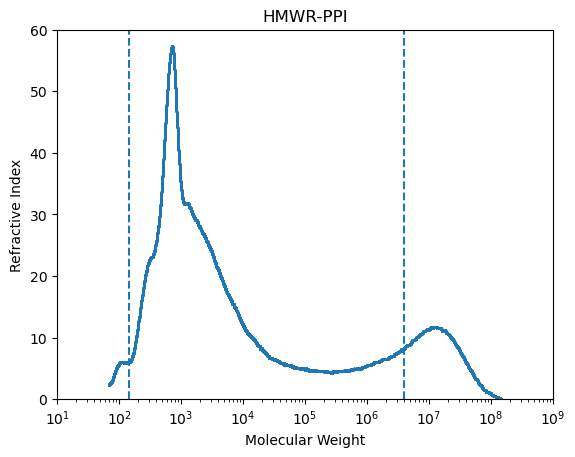

In [22]:
plt.title("HMWR-PPI")
plt.scatter(Data_HMWR_PPI_mp,Data_HMWR_PPI_ri,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.ylim(0,60)
plt.show()

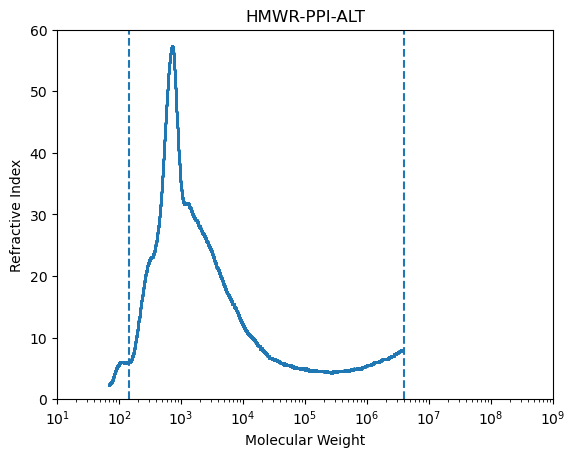

In [23]:
plt.title("HMWR-PPI-ALT")
plt.scatter(Data_HMWR_PPI_ALT_mp,Data_HMWR_PPI_ALT_ri,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.ylim(0,60)
plt.show()

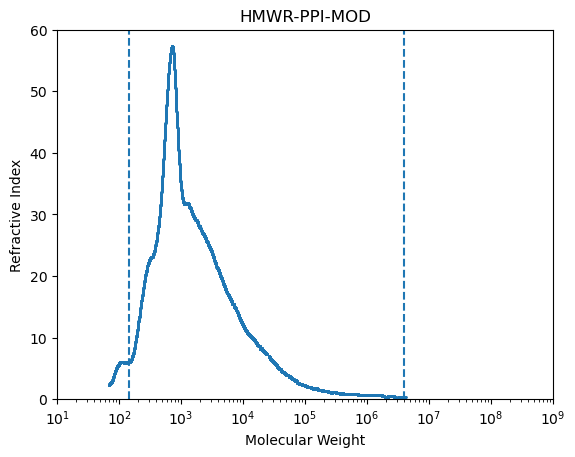

In [24]:
plt.title("HMWR-PPI-MOD")
plt.scatter(Data_HMWR_PPI_MOD_mp,Data_HMWR_PPI_MOD_ri,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.ylim(0,60)
plt.show()

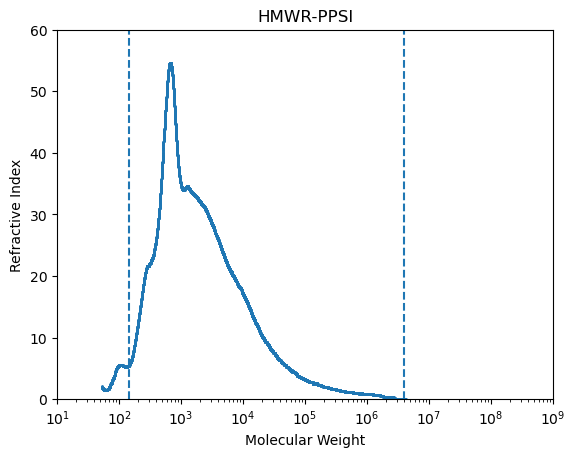

In [25]:
plt.title("HMWR-PPSI")
plt.scatter(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.ylim(0,60)
plt.show()

# Weight Fraction & Differential Distribution Y Axes

In [26]:
def TotalAreaFinder(MolecularWeightVals,RefractiveIndexVals):
    LasMolWeiVal = MolecularWeightVals[0]
    LasRefIndVal = RefractiveIndexVals[0]
    Areas = []
    for count,(MolWeiVal,RefIndVal) in enumerate(zip(MolecularWeightVals,RefractiveIndexVals)):
        if count == 0:
            continue
        else:
            CurMolWeiVal = MolWeiVal
            DifMolWeiVal = abs(CurMolWeiVal-LasMolWeiVal)
            CurRefIndVal = RefIndVal
            DifRefIndVal = abs(CurRefIndVal-LasRefIndVal)
            LowestRefIndVal = np.min(np.array([CurRefIndVal,LasRefIndVal]))
            TriangularArea = (DifRefIndVal*DifMolWeiVal)/2
            SquareArea = DifMolWeiVal*LowestRefIndVal
            TotalArea = TriangularArea+SquareArea
            Areas.append(TotalArea)
            LasMolWeiVal = CurMolWeiVal
            LasRefIndVal = CurRefIndVal
            continue
    Area = np.sum(np.array(Areas))
    return Area

In [27]:
# Specific Areas
Area_HMWR_PPI = TotalAreaFinder(Data_HMWR_PPI_mp,Data_HMWR_PPI_ri)
Area_HMWR_PPI_ALT = TotalAreaFinder(Data_HMWR_PPI_ALT_mp,Data_HMWR_PPI_ALT_ri)
Area_HMWR_PPI_MOD = TotalAreaFinder(Data_HMWR_PPI_MOD_mp,Data_HMWR_PPI_MOD_ri)
Area_HMWR_PPI_NT = TotalAreaFinder(Data_HMWR_PPI_NT_mp,Data_HMWR_PPI_NT_ri)
Area_HMWR_PPSI = TotalAreaFinder(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri)

In [28]:
print(round(Area_HMWR_PPI,0))
print(round(Area_HMWR_PPI_ALT,0))
print(round(Area_HMWR_PPI_MOD,0))
print(round(Area_HMWR_PPI_NT,0))
print(round(Area_HMWR_PPSI,0))

532288934.0
22271342.0
2824966.0
2477684.0
2810180.0


In [29]:
# Unified Area (To allow inter-comparison!)
Area_HMWR_PPI = 100000
Area_HMWR_PPI_ALT = 100000
Area_HMWR_PPI_MOD = 100000
Area_HMWR_PPI_NT = 100000
Area_HMWR_PPSI = 100000

In [30]:
def WeightFractionAndDifferentialDistributionFinder(MolecularWeightVals,RefractiveIndexVals,TotRefIndArea):
    LasMolWeiVal = MolecularWeightVals[0]
    LasRefIndVal = RefractiveIndexVals[0]
    NewMolWeiVals = []
    NewWeiFraVals = []
    NewDifDisVals = []
    for count,(MolWeiVal,RefIndVal) in enumerate(zip(MolecularWeightVals,RefractiveIndexVals)):
        if count == 0:
            continue
        else:
            CurMolWeiVal = MolWeiVal
            DifMolWeiVal = abs(CurMolWeiVal-LasMolWeiVal)
            HalDifMolWeiVal = DifMolWeiVal/2
            NewMolWeiVal = CurMolWeiVal+HalDifMolWeiVal
            NewMolWeiVals.append(NewMolWeiVal)
            
            CurRefIndVal = RefIndVal
            DifRefIndVal = abs(CurRefIndVal-LasRefIndVal)
            HalDifRefIndVal = DifRefIndVal/2
            LowestRefIndVal = np.min(np.array([CurRefIndVal,LasRefIndVal]))
            NewRefIndVal = LowestRefIndVal+HalDifRefIndVal

            NewWeiFraVal = NewRefIndVal/TotRefIndArea
            NewWeiFraVals.append(NewWeiFraVal)

            LogDifMolWeiVal = np.log(CurMolWeiVal)-np.log(LasMolWeiVal)
            NewDifDisVal = NewWeiFraVal/LogDifMolWeiVal
            NewDifDisVals.append(NewDifDisVal)
            
            LasMolWeiVal = CurMolWeiVal
            LasRefIndVal = CurRefIndVal
            continue
    return NewMolWeiVals,NewWeiFraVals,NewDifDisVals

In [31]:
Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_wf_Mod,Data_HMWR_PPI_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_HMWR_PPI_mp,Data_HMWR_PPI_ri,Area_HMWR_PPI)
Data_HMWR_PPI_ALT_mp_Mod,Data_HMWR_PPI_ALT_wf_Mod,Data_HMWR_PPI_ALT_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_HMWR_PPI_ALT_mp,Data_HMWR_PPI_ALT_ri,Area_HMWR_PPI_ALT)
Data_HMWR_PPI_MOD_mp_Mod,Data_HMWR_PPI_MOD_wf_Mod,Data_HMWR_PPI_MOD_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_HMWR_PPI_MOD_mp,Data_HMWR_PPI_MOD_ri,Area_HMWR_PPI_MOD)
Data_HMWR_PPI_NT_mp_Mod,Data_HMWR_PPI_NT_wf_Mod,Data_HMWR_PPI_NT_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_HMWR_PPI_NT_mp,Data_HMWR_PPI_NT_ri,Area_HMWR_PPI_NT)
Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_wf_Mod,Data_HMWR_PPSI_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri,Area_HMWR_PPSI)

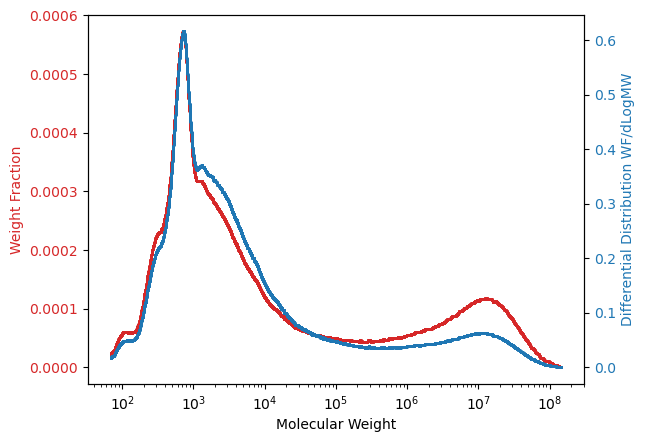

In [32]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_ylabel('Weight Fraction',color=color)
ax1.set_xlabel('Molecular Weight')
ax1.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_wf_Mod,s=1,label="PPI",color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Differential Distribution WF/dLogMW',color=color)
ax2.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_dd_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

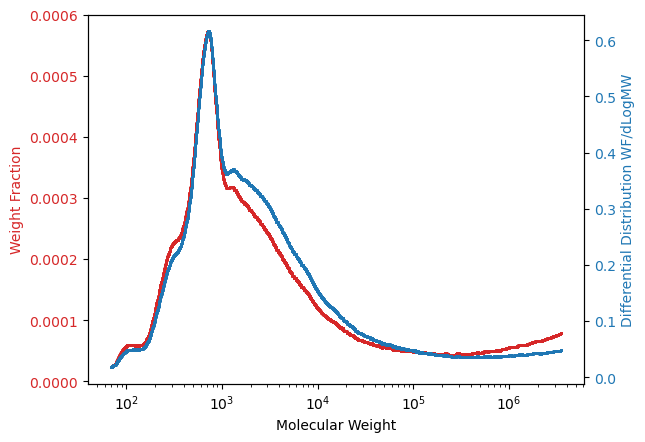

In [33]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_ylabel('Weight Fraction',color=color)
ax1.set_xlabel('Molecular Weight')
ax1.scatter(Data_HMWR_PPI_ALT_mp_Mod,Data_HMWR_PPI_ALT_wf_Mod,s=1,label="PPI_ALT",color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Differential Distribution WF/dLogMW',color=color)
ax2.scatter(Data_HMWR_PPI_ALT_mp_Mod,Data_HMWR_PPI_ALT_dd_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

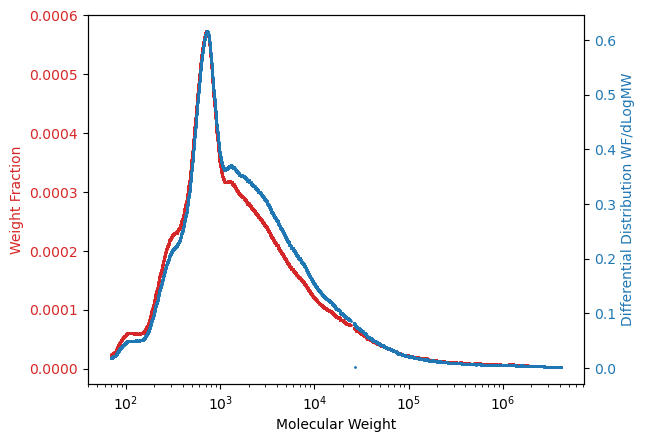

In [34]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_ylabel('Weight Fraction',color=color)
ax1.set_xlabel('Molecular Weight')
ax1.scatter(Data_HMWR_PPI_MOD_mp_Mod,Data_HMWR_PPI_MOD_wf_Mod,s=1,label="PPI_MOD",color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Differential Distribution WF/dLogMW',color=color)
ax2.scatter(Data_HMWR_PPI_MOD_mp_Mod,Data_HMWR_PPI_MOD_dd_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

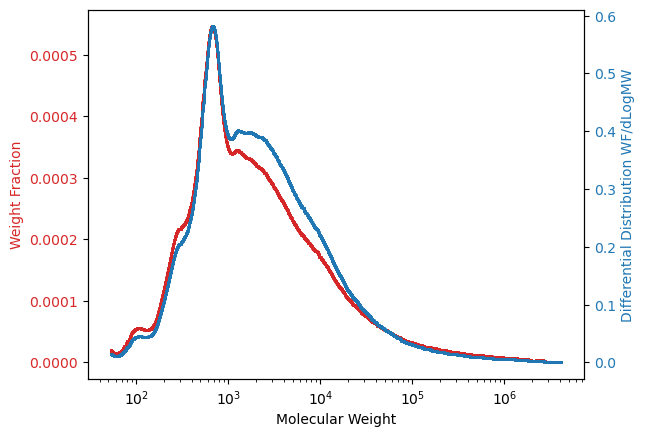

In [35]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_ylabel('Weight Fraction',color=color)
ax1.set_xlabel('Molecular Weight')
ax1.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_wf_Mod,s=1,label="PPSI",color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Differential Distribution WF/dLogMW',color=color)
ax2.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_dd_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

# Cumulative Weight Fraction

In [36]:
def CumulativeWeightFractionFinder(WeightFractionValues):
    CumulativeWeightFractions = []
    RunningWeightFraction = WeightFractionValues[0]
    for count,WeiFraVal in enumerate(WeightFractionValues):
        if count == 0:
            CumulativeWeightFractions.append(RunningWeightFraction)
            continue
        else:
            NewCumWeiFrac = RunningWeightFraction+WeiFraVal
            CumulativeWeightFractions.append(NewCumWeiFrac)
            RunningWeightFraction = NewCumWeiFrac
            continue
    TotalWeightFractions = CumulativeWeightFractions[-1]
    CumulativeNormalisedWeightFractions = np.array(CumulativeWeightFractions)/TotalWeightFractions
    return CumulativeNormalisedWeightFractions,TotalWeightFractions

In [37]:
Data_HMWR_PPI_cwf_Mod,HMWR_PPI_TotalWeightFractions = CumulativeWeightFractionFinder(Data_HMWR_PPI_wf_Mod)
Data_HMWR_PPI_ALT_cwf_Mod,HMWR_PPI_ALT_TotalWeightFractions = CumulativeWeightFractionFinder(Data_HMWR_PPI_ALT_wf_Mod)
Data_HMWR_PPI_MOD_cwf_Mod,HMWR_PPI_MOD_TotalWeightFractions = CumulativeWeightFractionFinder(Data_HMWR_PPI_MOD_wf_Mod)
Data_HMWR_PPI_NT_cwf_Mod,HMWR_PPI_NT_TotalWeightFractions = CumulativeWeightFractionFinder(Data_HMWR_PPI_NT_wf_Mod)
Data_HMWR_PPSI_cwf_Mod,HMWR_PPSI_TotalWeightFractions = CumulativeWeightFractionFinder(Data_HMWR_PPSI_wf_Mod)

In [38]:
print("The total weight fractions of the various curves:")
print(f"HMWR-PPI:\t{round(HMWR_PPI_TotalWeightFractions,2)}\t{round(HMWR_PPI_TotalWeightFractions/HMWR_PPI_TotalWeightFractions,2)}%")
print(f"HMWR-PPI-ALT:\t{round(HMWR_PPI_ALT_TotalWeightFractions,2)}\t{round(HMWR_PPI_ALT_TotalWeightFractions/HMWR_PPI_TotalWeightFractions,2)}%")
print(f"HMWR-PPI-MOD:\t{round(HMWR_PPI_MOD_TotalWeightFractions,2)}\t{round(HMWR_PPI_MOD_TotalWeightFractions/HMWR_PPI_TotalWeightFractions,2)}%")
print(f"HMWR-PPSI:\t{round(HMWR_PPSI_TotalWeightFractions,2)}")

The total weight fractions of the various curves:
HMWR-PPI:	1.74	1.0%
HMWR-PPI-ALT:	1.6	0.92%
HMWR-PPI-MOD:	1.45	0.84%
HMWR-PPSI:	1.64


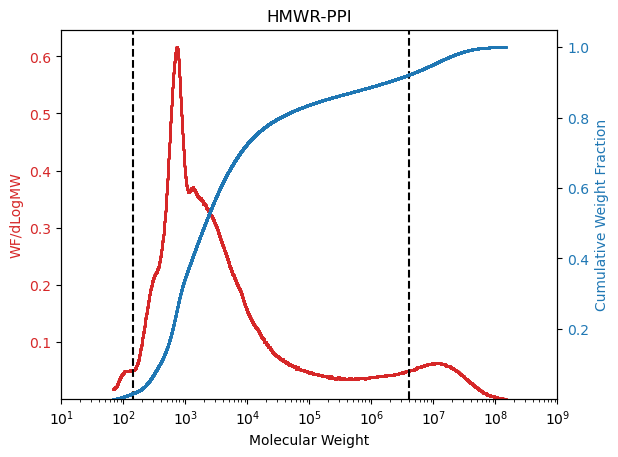

In [39]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPI_dd_Mod),np.max(Data_HMWR_PPI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPI_cwf_Mod),np.max(Data_HMWR_PPI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

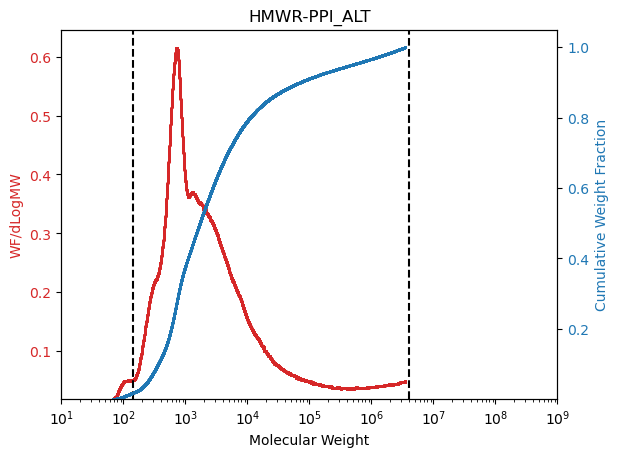

In [40]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPI_ALT")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPI_ALT_mp_Mod,Data_HMWR_PPI_ALT_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPI_ALT_mp_Mod,Data_HMWR_PPI_ALT_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPI_ALT_dd_Mod),np.max(Data_HMWR_PPI_ALT_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPI_ALT_cwf_Mod),np.max(Data_HMWR_PPI_ALT_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

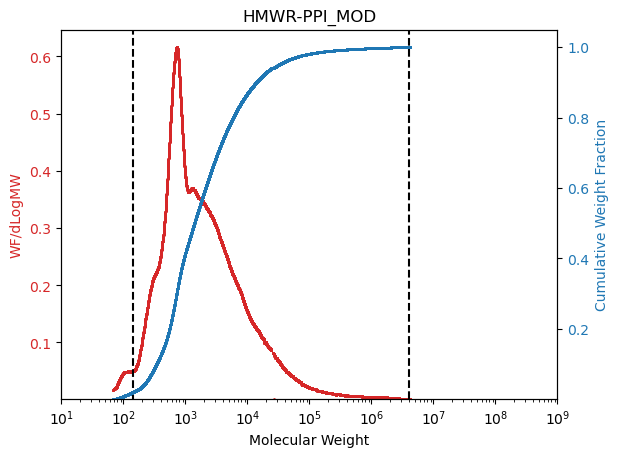

In [41]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPI_MOD")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPI_MOD_mp_Mod,Data_HMWR_PPI_MOD_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPI_MOD_mp_Mod,Data_HMWR_PPI_MOD_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPI_MOD_dd_Mod),np.max(Data_HMWR_PPI_MOD_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPI_MOD_cwf_Mod),np.max(Data_HMWR_PPI_MOD_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

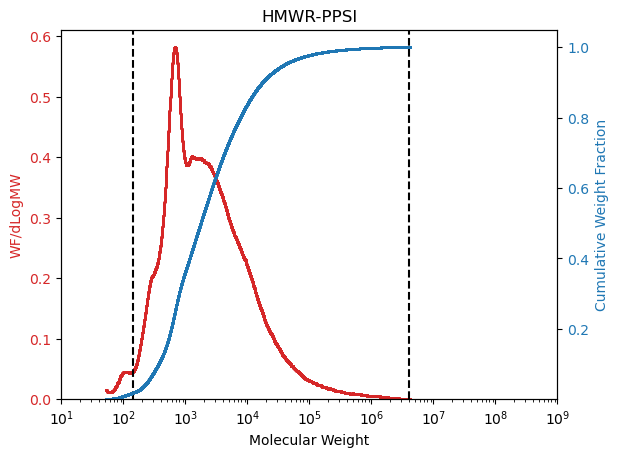

In [42]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPSI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPSI_dd_Mod),np.max(Data_HMWR_PPSI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPSI_cwf_Mod),np.max(Data_HMWR_PPSI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

# Finding Average Molecular Weights

In [43]:
def MolecularWeightFinder(RelativeIntensityData,RetentionVolumeData,MolecularMassData,IterativeSteps):
    MaximumRetentionVolume = np.max(RetentionVolumeData)
    MinimumRetentionVolume = np.min(RetentionVolumeData)
    RetentionVolumeRange = MaximumRetentionVolume-MinimumRetentionVolume
    VolumePerStep = RetentionVolumeRange/IterativeSteps

    IterativelyProducedAverages_ri = []
    IterativelyProducedAverages_mp = []
    CurrentVolume = MinimumRetentionVolume
    for step in range(IterativeSteps):
        if step+1 == IterativeSteps:
            LowerVolumeLimit = CurrentVolume
            UpperVolumeLimit = CurrentVolume+VolumePerStep

            LowerVolumeLimitIdx = 0
            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > LowerVolumeLimit:
                    LowerVolumeLimitIdx = count
                    break

            UpperVolumeLimitIdx = len(RetentionVolumeData)-1

            VolumeIdxRange = np.linspace(LowerVolumeLimitIdx,UpperVolumeLimitIdx,(UpperVolumeLimitIdx-LowerVolumeLimitIdx)+1).astype('int').tolist()
            
            Filtered_ri = np.array(RelativeIntensityData)[VolumeIdxRange]
            Filtered_mp = np.array(MolecularMassData)[VolumeIdxRange]

            ri_avg = np.average(Filtered_ri)
            mp_avg = np.average(Filtered_mp)

            IterativelyProducedAverages_ri.append(ri_avg)
            IterativelyProducedAverages_mp.append(mp_avg)
            break
        else:
            LowerVolumeLimit = CurrentVolume
            UpperVolumeLimit = CurrentVolume+VolumePerStep

            LowerVolumeLimitIdx = 0
            UpperVolumeLimitIdx = 0

            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > LowerVolumeLimit:
                    LowerVolumeLimitIdx = count
                    break
                
            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > UpperVolumeLimit:
                    UpperVolumeLimitIdx = count
                    break

            VolumeIdxRange = np.linspace(LowerVolumeLimitIdx,UpperVolumeLimitIdx,(UpperVolumeLimitIdx-LowerVolumeLimitIdx)+1).astype('int').tolist()
            
            Filtered_ri = np.array(RelativeIntensityData)[VolumeIdxRange]
            Filtered_mp = np.array(MolecularMassData)[VolumeIdxRange]

            ri_avg = np.average(Filtered_ri)
            mp_avg = np.average(Filtered_mp)

            IterativelyProducedAverages_ri.append(ri_avg)
            IterativelyProducedAverages_mp.append(mp_avg)

            CurrentVolume = UpperVolumeLimit
            continue

    # Number Average Molecular Weight
    a = np.sum(IterativelyProducedAverages_ri)
    b = np.array(IterativelyProducedAverages_ri)
    c = np.array(IterativelyProducedAverages_mp)
    d = b/c
    e = np.sum(d)
    f = a/e

    # Weight Average Molecular Weight
    g = b*c
    h = np.sum(g)
    i = h/a

    # Dispersity
    j = i/f

    return f,i,j # number average, weight average, dispersity

/var/folders/ms/cfmn5lqs2v594dwh_7kgcphm0000gn/T/ipykernel_81706/1722803812.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,10000000)


(33.14244860456968, 10000000)

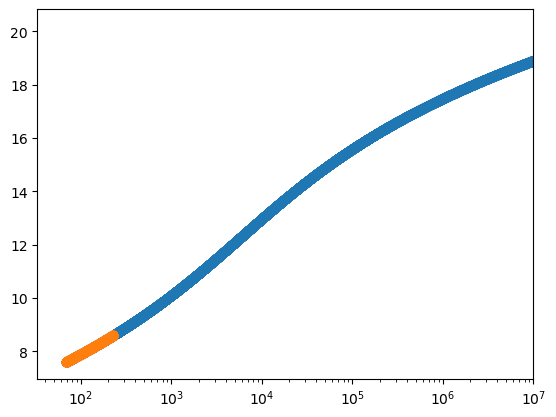

In [44]:
plt.scatter(Data_HMWR_PPI_mp,Data_HMWR_PPI_rv)
plt.scatter(Data_HMWR_PPI_mp[0:1000],Data_HMWR_PPI_rv[0:1000])
plt.xscale('log')
plt.ylim()
plt.xlim(0,10000000)

In [45]:
IterativeSteps = 1000
HMWR_PPI_NumAveMolWei,HMWR_PPI_WeiAveMolWei,HMWR_PPI_Disp = MolecularWeightFinder(Data_HMWR_PPI_ri,Data_HMWR_PPI_rv,Data_HMWR_PPI_mp,IterativeSteps)
HMWR_PPI_ALT_NumAveMolWei,HMWR_PPI_ALT_WeiAveMolWei,HMWR_PPI_ALT_Disp = MolecularWeightFinder(Data_HMWR_PPI_ALT_ri,Data_HMWR_PPI_ALT_rv,Data_HMWR_PPI_ALT_mp,IterativeSteps)
HMWR_PPI_MOD_NumAveMolWei,HMWR_PPI_MOD_WeiAveMolWei,HMWR_PPI_MOD_Disp = MolecularWeightFinder(Data_HMWR_PPI_MOD_ri,Data_HMWR_PPI_MOD_rv,Data_HMWR_PPI_MOD_mp,IterativeSteps)
HMWR_PPI_NT_NumAveMolWei,HMWR_PPI_NT_WeiAveMolWei,HMWR_PPI_NT_Disp = MolecularWeightFinder(Data_HMWR_PPI_NT_ri,Data_HMWR_PPI_NT_rv,Data_HMWR_PPI_NT_mp,IterativeSteps)
HMWR_PPSI_NumAveMolWei,HMWR_PPSI_WeiAveMolWei,HMWR_PPSI_Disp = MolecularWeightFinder(Data_HMWR_PPSI_ri,Data_HMWR_PPSI_rv,Data_HMWR_PPSI_mp,IterativeSteps)

In [46]:
print("Gel Permeation Chromatography")
print("=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-")
print("Two polystyrene samples of either high (HMWR) or low (LMWR) molecular weights used as standards.")
print("Two different samples have been trialled, one being a polymer of propylene glycol and itaconic acid (PPI) and the other also containing succinic acid (PPSI).")
print("Samples of PPI were run at 5 mg/ml whilst the PPSI samples were run at 10 mg/ml and the solvent was tetrahydrofuran.")
print("=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-")
print(f"Overview at {IterativeSteps} iterations across the retention volume handled:")
print()
print(f"\t\tNumber Average Mr\tWeight Average Mr\tDispersity")
print(f"HMWR-PPI:\t{round(HMWR_PPI_NumAveMolWei,2)}\t\t\t{round(HMWR_PPI_WeiAveMolWei,2)}\t\t{round(HMWR_PPI_Disp,2)}")
print(f"HMWR-PPI_ALT:\t{round(HMWR_PPI_ALT_NumAveMolWei,2)}\t\t\t{round(HMWR_PPI_ALT_WeiAveMolWei,2)}\t\t{round(HMWR_PPI_ALT_Disp,2)}")
print(f"HMWR-PPI_MOD:\t{round(HMWR_PPI_MOD_NumAveMolWei,2)}\t\t\t{round(HMWR_PPI_MOD_WeiAveMolWei,2)}\t\t\t{round(HMWR_PPI_MOD_Disp,2)}")
print(f"HMWR-PPSI:\t{round(HMWR_PPSI_NumAveMolWei,2)}\t\t\t{round(HMWR_PPSI_WeiAveMolWei,2)}\t\t{round(HMWR_PPSI_Disp,2)}")

Gel Permeation Chromatography
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
Two polystyrene samples of either high (HMWR) or low (LMWR) molecular weights used as standards.
Two different samples have been trialled, one being a polymer of propylene glycol and itaconic acid (PPI) and the other also containing succinic acid (PPSI).
Samples of PPI were run at 5 mg/ml whilst the PPSI samples were run at 10 mg/ml and the solvent was tetrahydrofuran.
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
Overview at 1000 iterations across the retention volume handled:

		Number Average Mr	Weight Average Mr	Dispersity
HMWR-PPI:	951.64			1559182.62		1638.42
HMWR-PPI_ALT:	873.85			95213.16		108.96
HMWR-PPI_MOD:	606.22			3005.51			4.96
HMWR-PPSI:	863.35			14734.83		17.07


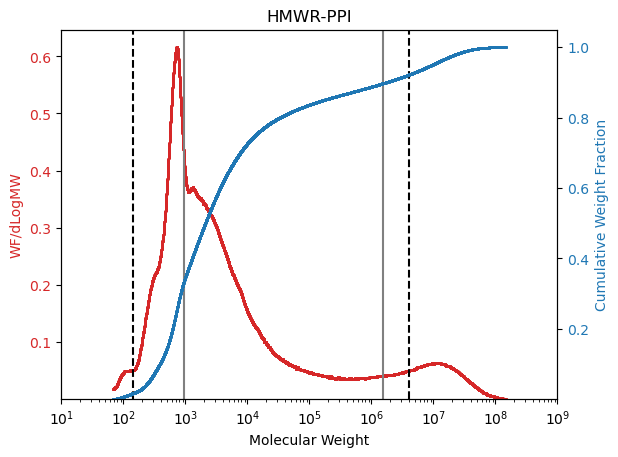

In [47]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPI_dd_Mod),np.max(Data_HMWR_PPI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPI_cwf_Mod),np.max(Data_HMWR_PPI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

ax1.axvline(ymin=0,ymax=1,x=HMWR_PPI_NumAveMolWei,color="grey")
ax1.axvline(ymin=0,ymax=1,x=HMWR_PPI_WeiAveMolWei,color="grey")

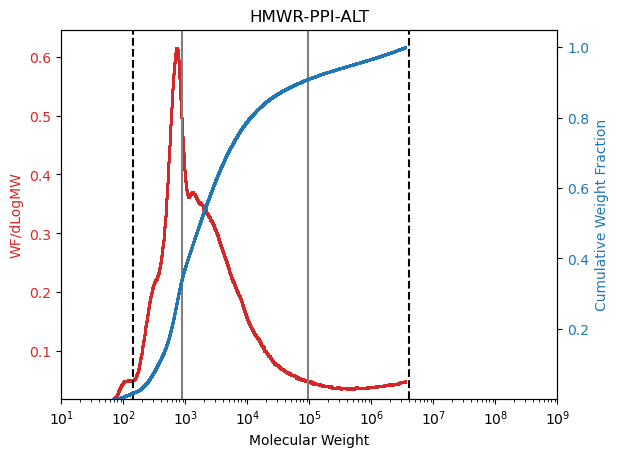

In [48]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPI-ALT")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPI_ALT_mp_Mod,Data_HMWR_PPI_ALT_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPI_ALT_mp_Mod,Data_HMWR_PPI_ALT_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPI_ALT_dd_Mod),np.max(Data_HMWR_PPI_ALT_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPI_ALT_cwf_Mod),np.max(Data_HMWR_PPI_ALT_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

ax1.axvline(ymin=0,ymax=1,x=HMWR_PPI_ALT_NumAveMolWei,color="grey")
ax1.axvline(ymin=0,ymax=1,x=HMWR_PPI_ALT_WeiAveMolWei,color="grey")

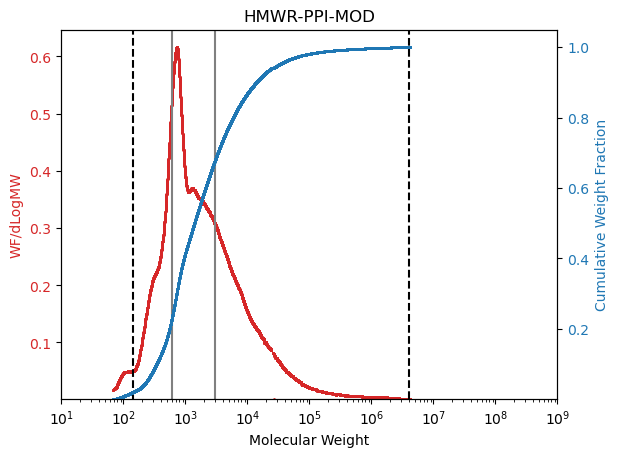

In [49]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPI-MOD")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPI_MOD_mp_Mod,Data_HMWR_PPI_MOD_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPI_MOD_mp_Mod,Data_HMWR_PPI_MOD_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPI_MOD_dd_Mod),np.max(Data_HMWR_PPI_MOD_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPI_MOD_cwf_Mod),np.max(Data_HMWR_PPI_MOD_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

ax1.axvline(ymin=0,ymax=1,x=HMWR_PPI_MOD_NumAveMolWei,color="grey")
ax1.axvline(ymin=0,ymax=1,x=HMWR_PPI_MOD_WeiAveMolWei,color="grey")

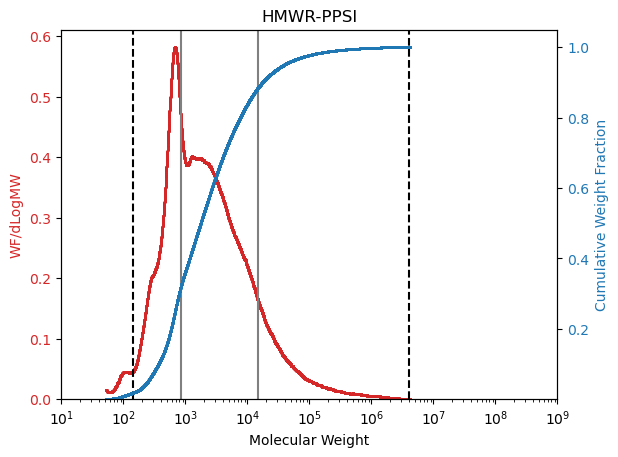

In [50]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPSI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPSI_dd_Mod),np.max(Data_HMWR_PPSI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPSI_cwf_Mod),np.max(Data_HMWR_PPSI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

ax1.axvline(ymin=0,ymax=1,x=HMWR_PPSI_NumAveMolWei,color="grey")
ax1.axvline(ymin=0,ymax=1,x=HMWR_PPSI_WeiAveMolWei,color="grey")

# Presenting the Data

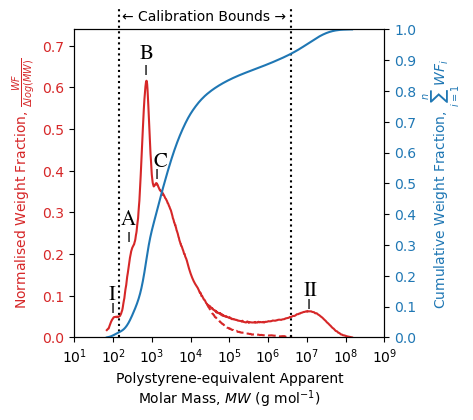

In [51]:
# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
color = 'tab:red'
ax1.set_xlabel(r"Polystyrene-equivalent Apparent"+"\n"+r"Molar Mass, $MW$ (g mol$^{-1})$")
ax1.set_ylabel(r"Normalised Weight Fraction, $\frac{WF}{\Delta log(MW)}$",color=color)
ax1.plot(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_dd_Mod,color=color)
ax1.plot(Data_HMWR_PPI_NT_mp_Mod,Data_HMWR_PPI_NT_dd_Mod,color=color,linestyle="dashed")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.set_xlim(10,1000000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000,1000000000])
ax1.set_ylim(0,np.max(Data_HMWR_PPI_dd_Mod)*1.2)

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel(r'Cumulative Weight Fraction, $\sum_{i=1}^{n}WF_{i}$',color=color)
ax2.plot(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_cwf_Mod,color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0,1)
ax2.set_yticks(np.linspace(0,1,11))

ax1.axvline(ymin=0,ymax=1.07,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dotted",color="black").set_clip_on(False)
ax1.axvline(ymin=0,ymax=1.07,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dotted",color="black").set_clip_on(False)

ax1.text(165,0.76,"← Calibration Bounds →")

ax1.text(75,0.09,"I",fontsize=15,font="times")
ax1.text(85,0.06,"I",fontsize=10)

ax1.text(8100000,0.1,"II",fontsize=15,font="times")
ax1.text(9700000,0.07,"I",fontsize=10)

ax1.text(160,0.27,"A",fontsize=15,font="times")
ax1.text(220,0.23,"I",fontsize=10)

ax1.text(480,0.67,"B",fontsize=15,font="times")
ax1.text(600,0.63,"I",fontsize=10)

ax1.text(1100,0.41,"C",fontsize=15,font="times")
ax1.text(1200,0.38,"I",fontsize=10)

plt.savefig(fname='Sample_PPI.png',bbox_inches="tight",dpi=1000,format='png')
# plt.savefig(fname='CorrectionalMethod.pdf',bbox_inches="tight",dpi=1000,format='pdf')

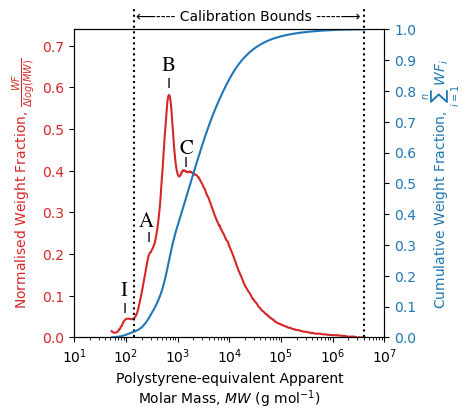

In [52]:
# PPSI
fig, ax1 = plt.subplots(figsize=(4,4))
color = 'tab:red'
ax1.set_xlabel(r"Polystyrene-equivalent Apparent"+"\n"+r"Molar Mass, $MW$ (g mol$^{-1})$")
ax1.set_ylabel(r"Normalised Weight Fraction, $\frac{WF}{\Delta log(MW)}$",color=color)
ax1.plot(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_dd_Mod,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.set_xlim(10,10000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000])
ax1.set_ylim(0,np.max(Data_HMWR_PPI_dd_Mod)*1.2)

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel(r'Cumulative Weight Fraction, $\sum_{i=1}^{n}WF_{i}$',color=color)
ax2.plot(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_cwf_Mod,color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0,1)
ax2.set_yticks(np.linspace(0,1,11))

ax1.axvline(ymin=0,ymax=1.07,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dotted",color="black").set_clip_on(False)
ax1.axvline(ymin=0,ymax=1.07,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dotted",color="black").set_clip_on(False)

ax1.text(155,0.76,"⟵---- Calibration Bounds -----⟶")

ax1.text(80,0.1,"I",fontsize=15,font="times")
ax1.text(85,0.06,"I",fontsize=10)

ax1.text(180,0.265,"A",fontsize=15,font="times")
ax1.text(250,0.23,"I",fontsize=10)

ax1.text(480,0.64,"B",fontsize=15,font="times")
ax1.text(600,0.60,"I",fontsize=10)

ax1.text(1100,0.44,"C",fontsize=15,font="times")
ax1.text(1300,0.41,"I",fontsize=10)

plt.savefig(fname='Sample_PPSI.png',bbox_inches="tight",dpi=1000,format='png')
# plt.savefig(fname='CorrectionalMethod.pdf',bbox_inches="tight",dpi=1000,format='pdf')

# hell

In [53]:
ppi_area = TotalAreaFinder(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_wf_Mod)
alt_area = TotalAreaFinder(Data_HMWR_PPI_ALT_mp_Mod,Data_HMWR_PPI_ALT_wf_Mod)
mod_area = TotalAreaFinder(Data_HMWR_PPI_MOD_mp_Mod,Data_HMWR_PPI_MOD_wf_Mod)
ppsi_area = TotalAreaFinder(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_wf_Mod)

In [54]:
from numpy import trapz
ppi_area = np.trapz(x=Data_HMWR_PPI_mp_Mod,y=Data_HMWR_PPI_wf_Mod)
alt_area = np.trapz(x=Data_HMWR_PPI_ALT_mp_Mod,y=Data_HMWR_PPI_ALT_wf_Mod)
mod_area = np.trapz(x=Data_HMWR_PPI_MOD_mp_Mod,y=Data_HMWR_PPI_MOD_wf_Mod)
ppsi_area = np.trapz(x=Data_HMWR_PPSI_mp_Mod,y=Data_HMWR_PPSI_wf_Mod)

In [55]:
print(np.trapz(x=Data_HMWR_PPI_mp_Mod,y=Data_HMWR_PPI_dd_Mod))
print(np.trapz(x=Data_HMWR_PPI_ALT_mp_Mod,y=Data_HMWR_PPI_ALT_dd_Mod))
print(np.trapz(x=Data_HMWR_PPI_MOD_mp_Mod,y=Data_HMWR_PPI_MOD_dd_Mod))

2714672.024307586
151859.45743657232
22567.03228537285


In [56]:
print("The total weight fractions of the various curves:")
print(f"HMWR-PPI:\t{round(ppi_area,2)}\t{round(ppi_area/ppi_area,2)}%")
print(f"HMWR-PPI-ALT:\t{round(alt_area,2)}\t{round(alt_area/ppi_area,2)}%")
print(f"HMWR-PPI-MOD:\t{round(mod_area,2)}\t{round(mod_area/ppi_area,2)}%")
print(f"HMWR-PPSI:\t{round(ppsi_area,2)}")

The total weight fractions of the various curves:
HMWR-PPI:	5334.37	1.0%
HMWR-PPI-ALT:	222.85	0.04%
HMWR-PPI-MOD:	28.28	0.01%
HMWR-PPSI:	28.14
